<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/11_hyperparameter_search_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11. Hyperparameter Search (Grid & Random) — PyTorch

We *search* hyperparameters instead of fixing them: a **grid search** over learning rate × batch size (with a heatmap), then a **random search** over a wider space. The training loop is the explicit PyTorch one you've used throughout.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

> This is the PyTorch twin of `11_..._keras.ipynb`. Where Keras hides the training loop inside `model.fit`, here we **write the loop explicitly** — that is the main thing to compare.

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cpu | device: cpu


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

Features are already scaled to `[0,1]`; we drop the ID and do a **stratified** split.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
# Wrap the numpy arrays as float tensors. Target is shaped (N,1) to match the
# sigmoid output and BCELoss.
Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train).view(-1, 1)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test).view(-1, 1)
print("Xtr", tuple(Xtr.shape), "| ytr", tuple(ytr.shape))

Xtr (491, 11) | ytr (491, 1)


In [5]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test (dashed) loss and accuracy over epochs."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["accuracy"], label="train")
    ax[1].plot(hist["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. A reusable train-and-score function

Each trial rebuilds the same architecture from the same seed and returns the best test accuracy — differences come only from the hyperparameters. Epochs are kept modest (40) because a search trains many models.

In [6]:
import itertools

def train_score(lr, batch_size, units=32, epochs=40):
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(N_FEATURES, units), nn.ReLU(),
        nn.Linear(units, 1), nn.Sigmoid(),
    )
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    best = 0.0
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            acc = (((model(Xte) > 0.5) == (yte > 0.5)).float().mean()).item()
        best = max(best, acc)
    return best

## 5. Grid search: learning rate × batch size

In [7]:
lr_grid    = [0.0003, 0.001, 0.003, 0.01]
batch_grid = [16, 32, 64]

records = []
for lr, bs in itertools.product(lr_grid, batch_grid):
    acc = train_score(lr, bs)
    records.append({"lr": lr, "batch_size": bs, "best_test_acc": acc})
    print("lr=%.4f  batch=%-3d -> best test acc = %.4f" % (lr, bs, acc))

grid_df = pd.DataFrame(records)
best = grid_df.loc[grid_df["best_test_acc"].idxmax()]
print("\nBest grid config: lr=%.4f, batch=%d -> acc=%.4f" %
      (best["lr"], best["batch_size"], best["best_test_acc"]))

lr=0.0003  batch=16  -> best test acc = 0.8049


lr=0.0003  batch=32  -> best test acc = 0.7073


lr=0.0003  batch=64  -> best test acc = 0.7073


lr=0.0010  batch=16  -> best test acc = 0.8537


lr=0.0010  batch=32  -> best test acc = 0.8537


...

lr=0.0030  batch=32  -> best test acc = 0.8618


lr=0.0030  batch=64  -> best test acc = 0.8618


lr=0.0100  batch=16  -> best test acc = 0.8618


lr=0.0100  batch=32  -> best test acc = 0.8618


lr=0.0100  batch=64  -> best test acc = 0.8618

Best grid config: lr=0.0030, batch=16 -> acc=0.8618


## 6. Heatmap of the grid

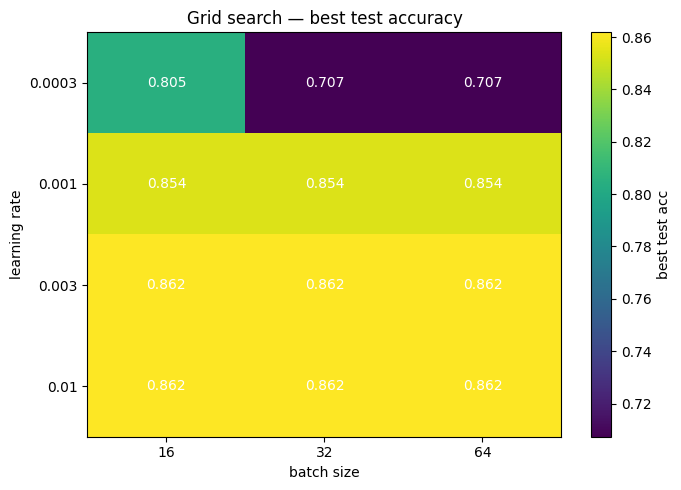

In [8]:
pivot = grid_df.pivot(index="lr", columns="batch_size", values="best_test_acc")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_xlabel("batch size"); ax.set_ylabel("learning rate")
ax.set_title("Grid search — best test accuracy")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, "%.3f" % pivot.values[i, j], ha="center", va="center", color="w")
fig.colorbar(im, ax=ax, label="best test acc")
plt.tight_layout(); plt.show()

## 7. Random search

With the same budget, random sampling usually explores the important axes better than a rigid grid. We sample the learning rate **log-uniformly** so every order of magnitude gets equal attention, and fix the NumPy seed for reproducibility.

In [9]:
rng = np.random.default_rng(0)          # fixed seed -> reproducible search
N_TRIALS = 8

rand_records = []
for t in range(N_TRIALS):
    lr = float(10 ** rng.uniform(-4, -2))     # log-uniform in [1e-4, 1e-2]
    bs = int(rng.choice([16, 32, 64]))
    units = int(rng.choice([16, 32, 64]))
    acc = train_score(lr, bs, units=units)
    rand_records.append({"lr": round(lr, 5), "batch_size": bs, "units": units,
                         "best_test_acc": round(acc, 4)})
    print("trial %d: lr=%.5f batch=%-3d units=%-2d -> acc=%.4f" % (t, lr, bs, units, acc))

rand_df = pd.DataFrame(rand_records).sort_values("best_test_acc", ascending=False)
rand_df.reset_index(drop=True)

trial 0: lr=0.00188 batch=32  units=16 -> acc=0.8618


trial 1: lr=0.00012 batch=16  units=16 -> acc=0.6911


trial 2: lr=0.00423 batch=32  units=64 -> acc=0.8618


trial 3: lr=0.00163 batch=64  units=64 -> acc=0.8618


trial 4: lr=0.00122 batch=32  units=64 -> acc=0.8618


trial 5: lr=0.00428 batch=64  units=16 -> acc=0.8618


trial 6: lr=0.00519 batch=32  units=16 -> acc=0.8618


trial 7: lr=0.00288 batch=64  units=16 -> acc=0.8618


,lr,batch_size,units,best_test_acc
0,0.00188,32,16,0.8618
1,0.00423,32,64,0.8618
2,0.00163,64,64,0.8618
3,0.00122,32,64,0.8618
4,0.00519,32,16,0.8618
5,0.00428,64,16,0.8618
6,0.00288,64,16,0.8618
7,0.00012,16,16,0.6911


## 8. Best configuration found

In [10]:
best_grid = grid_df.loc[grid_df["best_test_acc"].idxmax()]
best_rand = rand_df.iloc[0]
print("Grid   best: lr=%.4f batch=%d           -> acc=%.4f" %
      (best_grid["lr"], best_grid["batch_size"], best_grid["best_test_acc"]))
print("Random best: lr=%.5f batch=%d units=%d  -> acc=%.4f" %
      (best_rand["lr"], best_rand["batch_size"], best_rand["units"], best_rand["best_test_acc"]))

Grid   best: lr=0.0030 batch=16           -> acc=0.8618
Random best: lr=0.00188 batch=32 units=16  -> acc=0.8618


## Takeaways
- **Grid search** cost is the *product* of the axes — it scales badly; **random search** samples and usually matches or beats it under the same budget.
- Sample learning rate **log-uniformly** (`10 ** uniform(-4, -2)`) — the right prior for a parameter that spans orders of magnitude.
- Rebuild from a fixed seed each trial so the score reflects the *hyperparameters*, not the init.
- Unlike Keras (which has **KerasTuner**), PyTorch users typically reach for **Optuna** or **Ray Tune** for smarter (Bayesian / Hyperband) search — but the manual loop here is the core idea they automate.
- This wraps the series: baseline → every training technique → schedules → tuning.